### `Débruitage par Sobolev et régularisation de variation totale`

*Important:* Please read the [installation page](http://gpeyre.github.io/numerical-tours/installation_python/) for details about how to install the toolboxes.

- This numerical tour explores the use of variational minimization to perform denoising. 
- It consider the Sobolev and the Total Variation regularization functional (priors).

In [2]:
import sys, os

# chemin ABSOLU vers le dossier qui contient nt_toolbox
toolbox_parent = r"/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle"
sys.path.insert(0, toolbox_parent)

from nt_toolbox.general import *
from nt_toolbox.signal import *

In [3]:
from __future__ import division
import nt_toolbox as nt
#from nt_solutions import denoisingsimp_4_denoiseregul as solutions
%matplotlib inline
%load_ext autoreload
%autoreload 2

#### `Prior and Regularization`
Pour une image $f$ donnée $J(f) \in \mathbb{R}$ associe un score qui est supposé être faible pour l’image d’intérêt. 
Le débruitage d’une image y est obtenu par une minimisation variationnelle qui combine un ajustement aux données (généralement via une norme $L^2$ ) et l’a priori.
$$ \min_f \frac{1}{2}\|y-f\|^2 + \lambda J(f) $$
 - Si $J(f)$ est une fonction convexe de $f$, alors le minimum existe et il est unique. 

Le paramètre  $\tau>0$ doit être adapté au niveau de bruit, accroitre sa valeur moyenne rend le débruitage plus agressif. 

Si $J(f)$ est un fonction continue de l'image $f$, un minimiseur de ce problème peut être calculé par descente de gradient. Cela définit une suite d’images $f^{(\ell)}$ indexed by $\ell \in \mathbb{N}$
tel que : 
$$ f^{(\ell+1)} = f^{(\ell)} + \tau \left( f^{(\ell)}-y + \lambda \text{Grad}J(f^{(\ell)}) \right). $$


Notons que $f^{(\ell)}$ converge vers une solution du problème lorsque $\ell \rightarrow +\infty$
$\large \tau$ requiert d'être suffisamment faible, plus précisément, si la fonction $J$ est deux fois différenciable
$$ \tau < \frac{2}{1 + \lambda \max_f \|D^2 J(f)\|}. $$

`«Apriori de Sobolev»`
 - L’apriori d’image de Sobolev est un a priori quadratique, c’est‑à‑dire une (pseudo-)norme de Hilbert.
 - « Nous chargeons d’abord une image propre (sans bruit). »

In [5]:
n = 256
path= '/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle/'
name = path + 'nt_toolbox/data/hibiscus.bmp'
f0 = load_image(name, n)
print(f0.shape)
# normalise l'image, pour l’affichage et les paramètres (bruit, λ, etc.).
f0 = rescale(f0)

(256, 256)


Pour une fonction $f$ continue et régulière, définit par : 
 - $J(f) = \int \|\nabla f(x)\|^2 d x $ est la version continue de la somme discrète de $J_{disc}(f)≈ \sum_{i,j}||\nabla f_{i,j}||^2$
 - où le gradient au point $x$ et définit tel que : $\nabla f(x) = \large \left(  \frac{\partial f(x)}{\partial x_1},\frac{\partial f(x)}{\partial x_2} \right)$
Une image discrète pixélisée $f \in \mathbb{R}^N$ où $N=n \times n$ le nombre de pixel $\nabla f(x) \in \mathbb{R}^2$ calculé à l’aide de différences finies.

In [87]:
Gr = grad(f0)
print(Gr.shape)

(256, 256, 2)


Calcule de la norme euclidienne $L_2$ du gradient $d(x) = \|\nabla f(x)\| $ en chaque pixel : $d(i,j)= \sqrt{(∂_x f(i,j))^2 +(∂_yf(i,j))^2}$

In [56]:
#l_2 = np.sqrt(np.sum(Gr**2, axis=2))
l_2 = np.sqrt(Gr[:,:,0]**2+Gr[:,:,1]**2)
print(f"d.shape : {l_2.shape}")

d.shape : (256, 256)


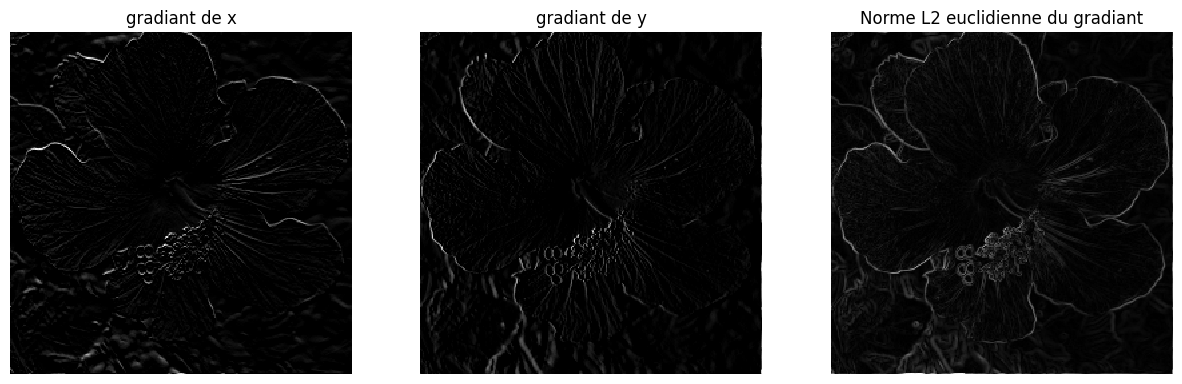

In [54]:
plt.figure(figsize=(15, 7))
imageplot(clamp(Gr[:, :, 0]), 'gradiant de x', [1, 3, 1])
imageplot(clamp(Gr[:, :, 1]), 'gradiant de y', [1, 3, 2])
imageplot(clamp(l_2),         'Norme L2 euclidienne du gradiant', [1, 3, 3])

« La norme de Sobolev est la norme au carré $L^2$ du gradiant $\nabla f \in\mathbb{R}^{N \times 2}$.

In [88]:
J_disc = np.sum(l_2)
print(f"J_disc : {J_disc}")
J_disc_sobolev = np.sum(l_2**2)
print(f"La vraie énergie Sobolev pour une image f est, en version discrète : {J_disc_sobolev}")

J_disc : 2375.915255352606
La vraie énergie Sobolev pour une image f est, en version discrète : 229.17343184673206


### `Débruitage, régularisation de type chaleur`
 - `La régularisation de type chaleur, lisse l’image à l’aide d’un filtre passe‑bas`. 
 - `Augmenter la valeur de` $∣\sigma∣$ `augmente la quantité de lissage`. 
 - `On ajoute du bruit à l’image originale`.

    - $f_0$ image réelle 
    - $y$ image $f_0$ bruitée

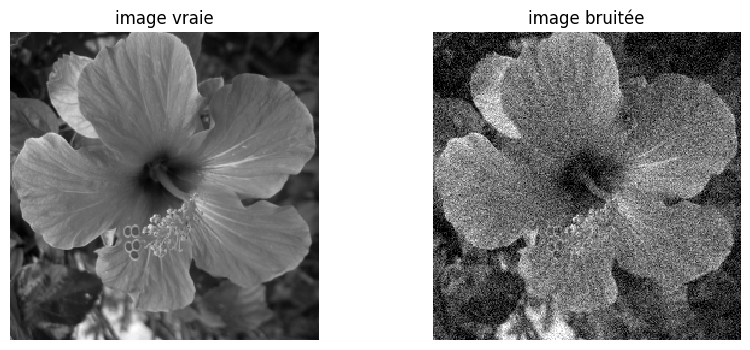

In [58]:
sigma = .1
y = f0 + np.random.randn(n, n)*sigma
plt.figure(figsize=(10, 4))
imageplot(clamp(f0),'image vraie', [1,2,1])
imageplot(clamp(y),'image bruitée', [1,2,2])

$f^{\star}$ `la régularisation de Sobolev peut-être calculé en utilisant la transformée de Fourier` : 
- La norme de Sobolev est un objet purement mathématique. 
- la régularisation de Sobolev est l’utilisation de cette norme comme pénalité dans un problème d’optimisation (débruitage).
- $ \hat f^{\star}(\omega) = \large \frac{\hat y(\omega)}{ 1+\lambda S(\omega) } \quad$ $\text{où}\quad S(\omega)=\|\omega\|^2. $


   - montre que $f^{\star}$ est un filtre de $y$.
   - utile pour la transformée de Fourier des observations.

In [59]:
# Tranformée de Fourier d'une image bruitée 
yF = np.fft.fft2(y)

Grille de fréquences : table des coordonnées de chaque fréquence ($ω_x ,ω_y$) associée à un coefficient de la T.Fourier 2D.

`Du signal 2D aux fréquences` 
   - pour une image $n×n$, sa transformée de Fourier 2D $yF = np.fft.fft2(y)$ est un tableau $n×n$. 
   - chaque case yF[i, j] correspond à une fréquence discrète ($ω_x ,ω_y$). 
   - pour appliquer `un filtre qui dépend de`$ω$ (comme $S(ω)=||ω||^2$ ), 
   - on a besoin de connaître ces $ω_x ,ω_y$  pour chaque indice $(i,j)$.
   - pour chaque fréquence $ω=(ω_x,ω_y)$ $S(\omega)=||\omega||^2(\large \frac{2}{n})^2$ 

In [67]:
t = np.concatenate( (np.arange(0,n/2), np.arange(-n/2,0) ) ) 
[Y,X] = np.meshgrid(t, t)
# un filtre qui dépend de ω S(ω)=||ω||^2, pour chaque fréquence S(ω)
Sω = (X**2 + Y**2) * (2 / n)**2
Sω.shape

(256, 256)

__`Calculer la pénalité a priori de Sobolev S (la ramener dans l’intervalle [0,1])`__

In [74]:
Sω = (X**2 + Y**2) * (2 / n)**2

Sω_min = Sω.min()
Sω_max = Sω.max()

Sω_norm = (Sω - Sω_min) / (Sω_max - Sω_min)
# Sω_norm a maintenant des valeurs dans [0,1]
J_disc_sobolev = np.sum(Sω_norm**2)
print(f"J_disc_sobolev : {J_disc_sobolev:.3f}")

J_disc_sobolev : 10195.378


__`Effectuer le débruitage par filtrage`__
Débruitage de l'image dans le domaine fréquentiel : $\hat f^⋆(\omega)= \Large \frac{\hat y(\omega)}{1+λS(\omega)}$  avec le paramètre de `régularization` lambda

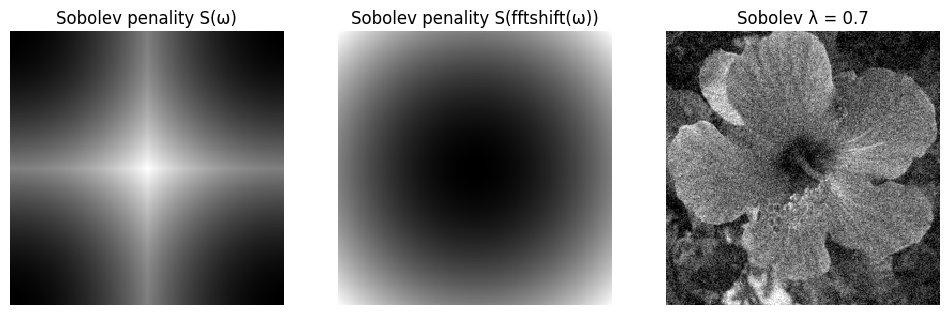

In [ ]:
lambd = 0.7
fsob = lambda yF,lambd,Sω : np.real(np.fft.ifft2(yF / (1 + lambd * Sω)))
fSob = fsob(yF,lambd, Sω)
plt.figure(figsize=(12, 4))
imageplot(Sω_norm, 'Sobolev penality S(ω) sans fftshift', [1,3,1])
imageplot(np.fft.fftshift(Sω_norm), 'Sobolev penality S(ω) avec fftshift', [1,3,2])
imageplot(clamp(fSob),f'Sobolev λ = {lambd}', [1,3,3])

- __Avec fftshift on recentre les basses fréquences__ pour une visualisation intuitive (centre sombre).      
- __Sans fftshift, les coins ≈ basses fréquences__, le centre et les bords ≈ fréquences plus élevées.
   - `Les zones claires sont les fréquences fortement pénalisées`, 
   - `Les foncées les fréquences peu pénalisées`,

### __`Exercice 1`__

Caculer la solution pour plusieurs valeur de $\lambda$ et choisir la valeur optimale de débruitage correspondant à |fSob0|. Accroitre progressivement $\lambda$ et réuire le nombre d'itérations. 

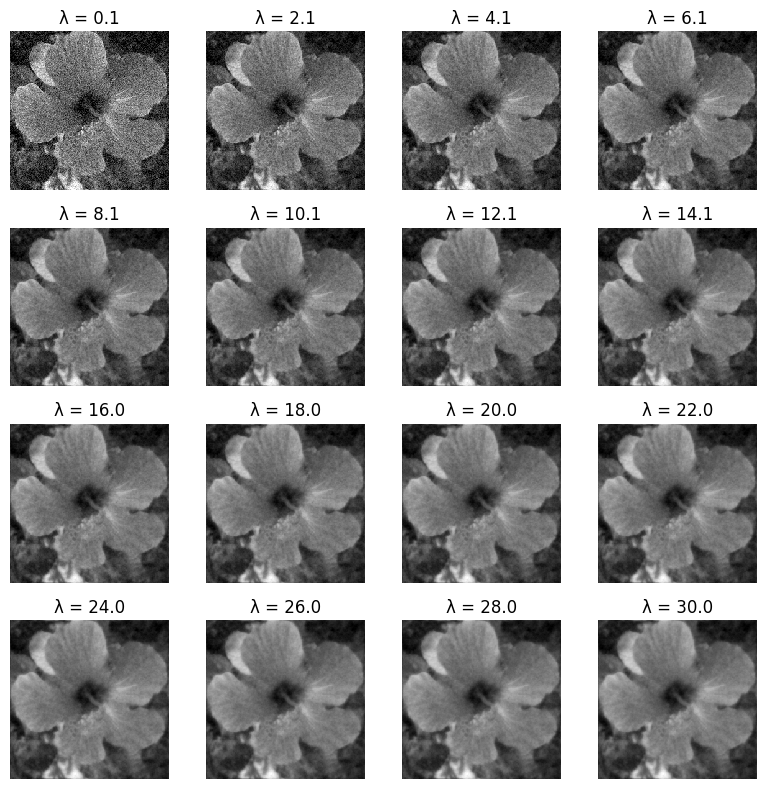

In [97]:
import matplotlib.pyplot as plt
import numpy as np

lambda_list = np.linspace(0.1,30,16)
ncols = 4
nimgs = len(lambda_list)
nrows = int(np.ceil(nimgs / ncols))

plt.figure(figsize=(8,8))

for i, lambd in enumerate(lambda_list):
    plt.subplot(nrows, ncols, i+1)
    imageplot(clamp(fsob(yF,lambd,Sω)), f"λ = {lambd:.1f}", [])
    plt.axis('off')

plt.tight_layout()
plt.show()

`Pourquoi est-ce « peu intéressant »`
La pénalité Sobolev $S_ω ∝||ω||^2$  correspond à une régularisation quadratique sur le gradient $(∫||∇f||^2)$, qui favorise des solutions très lisses mais ne respecte pas bien les bords et structures fines.

Sur une image réelle avec beaucoup de texture, ce type de régularisation a vite le comportement d’un flou gaussien : compromis bruit/flou, mais pas de préservation nette des contours.

__`Formule SNR`__
Avec une image propre $f_0$ et une reconstruction $f_{Sob}$, le SNR (en dB) se définit par : $SNR=20*log_{10} \Large \frac {||f_0||^2}{||f_0−f_{Sob}||^2}$


In [ ]:
def snr(x, y):
    num = np.linalg.norm(x)          # ||x||
    den = np.linalg.norm(x - y)      # ||x - y||
    return 20 * np.log10(num / den)

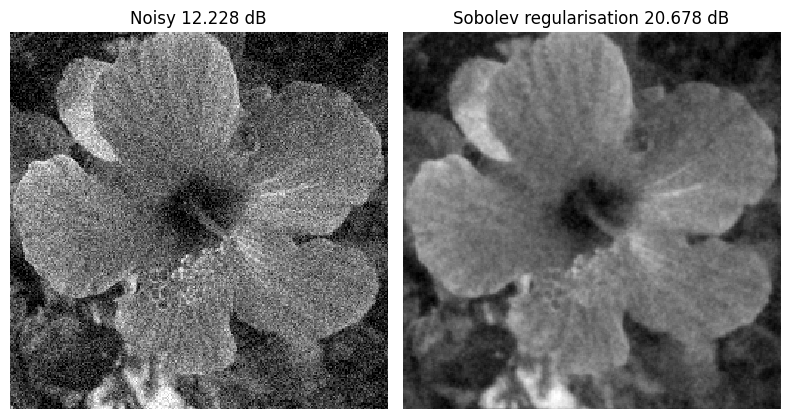

In [ ]:
enoisy = snr(f0, y)  # image bruitée 
esob = snr(f0, fSob) # image regularisée Sobolev

plt.figure(figsize=(8,8))

imageplot(clamp(y),    f"Noisy {enoisy:.3f} dB",    [1, 2, 1])
imageplot(clamp(fSob), f"Sobolev regularisation {esob:.3f} dB", [1, 2, 2])

plt.tight_layout()
plt.show()

#### `A priori de variation totale`
La variation totale est une norme qui contrairement à la norme de Sobolev, est capable de prendre en compte les discontinuités de type marches (bords nets).
- La variation totale d’une image lisse $f$ est définie par $J(f) = \int \|\nabla f(x)\| \,\mathrm{d}x$.
- Elle s’étend aux images non lisses présentant des discontinuités en marche. 
- La variation totale d’une image est égale à la longueur totale de ses ensembles de niveau : 

   - $J(f) = TV(f) = \int_{-\infty}^{+\infty} L(S_t(f)) \,\mathrm{d}t$

      - où $S_t(f)$ désigne l’ensemble de niveau $\{x∈Ω:f(x)=t\}$ de l’image $f$, $S_t(f) = \{ x \mid f(x) = t \}$
      - et $L(S_t(f))$ sa longueur (périmètre)

##### __`Exercise 2 : Calculer la variation totale de`__ $|f_0|$
Pour une image discrète, on approxime cette intégrale par une somme sur les pixels.
`Formule discrète` 
 - si l'image est $f∈R^{n×n}$
 - que $grad(f)$ renvoie un tableau Gr de taille (n, n, 2) dérivées finies en x et y, 
 - alors la TV isotrope se calcule par : $J(f)≈\sum_{i,j}||∇f_{i,j}||=\sum_{i,j}\sqrt{(∂_xf_{i,j})^2+(∂_yf_{i,j})^2}$


In [ ]:
eps = 0.5   # par exemple
l_2 = np.sqrt(Gr[:, :, 0]**2 + Gr[:, :, 1]**2)        # ||∇f|
J_tv_eps = np.sum(np.sqrt(eps**2 + l_2**2))
print(f"J_tv_eps : {J_tv_eps}")

J_tv_eps : 32985.0361744687


Pour une image $f$ donnée $J(f) \in \mathbb{R}$ associe un score qui est supposé être faible pour l’image d’intérêt. 
Le débruitage de y est obtenu par minimisation variationnelle combinant un ajustement aux données $ \min_f \frac{1}{2}\|f - y\|^2 + \lambda J(f) $ 
Si $J(f)$ est une fonction convexe de $f$, alors le minimum existe et il est unique. 

__`Le Gradient de la norme TV :`__ 
$ \text{Grad}J(f) = \text{div}\left(\large \frac{\nabla f}{\|\nabla f\|} \right) $ non défini au pixel $x$ si $\nabla f(x)=0$ difficile à minimiser, le flot de gradient est mal défini.
Considérons une nomalisation douce de TV : $J_\epsilon(f) = \int \sqrt{ \varepsilon^2 + \| \nabla f(x) \|^2 } dx $ 
  - Ici $||u||$ la norme euclidienne du vecteur $u$. 
  - On substitue $\|u\|$ par $ \sqrt{\varepsilon^2 + \|u\|^2} $ qui est la fonction lissée


We display (in 1D) the smoothing of the absolute value.

1.000050199341617


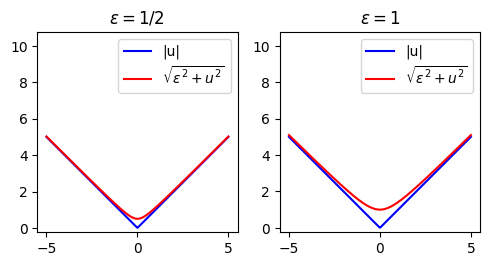

In [184]:
import numpy as np
import matplotlib.pyplot as plt

u = np.linspace(-5, 5, 500)  # vecteur 1D

plt.figure(figsize=(5, 8))

val = np.sqrt(eps**2 + u**2)
min = np.argmin(val)
print(val[min])

# epsilon = 0.5
eps = 0.5
plt.subplot(1, 2, 1)
plt.plot(u, np.abs(u), 'b', label='|u|')
plt.plot(u, np.sqrt(eps**2 + u**2), 'r', label=r'$\sqrt{\varepsilon^2 + u^2}$')
plt.title(r'$\varepsilon = 1/2$')
plt.axis('square')
plt.legend()

# epsilon = 1
eps = 1.0
plt.subplot(1, 2, 2)
plt.plot(u, np.abs(u), 'b', label='|u|')
plt.plot(u, np.sqrt(eps**2 + u**2), 'r', label=r'$\sqrt{\varepsilon^2 + u^2}$')
plt.title(r'$\varepsilon = 1$')
plt.axis('square')
plt.legend()

plt.tight_layout()
plt.show()


Le gradiant de la norme TV lissé est :  $ \text{Grad}J(f) = \text{div}\left( \frac{\nabla f}{\sqrt{\varepsilon^2 + \|\nabla f\|^2}} \right)$


 - Lorsque $\varepsilon$ augmente, le gradiant de la norme TV lissé approche le Laplacian (normalisé par $1/\varepsilon$).

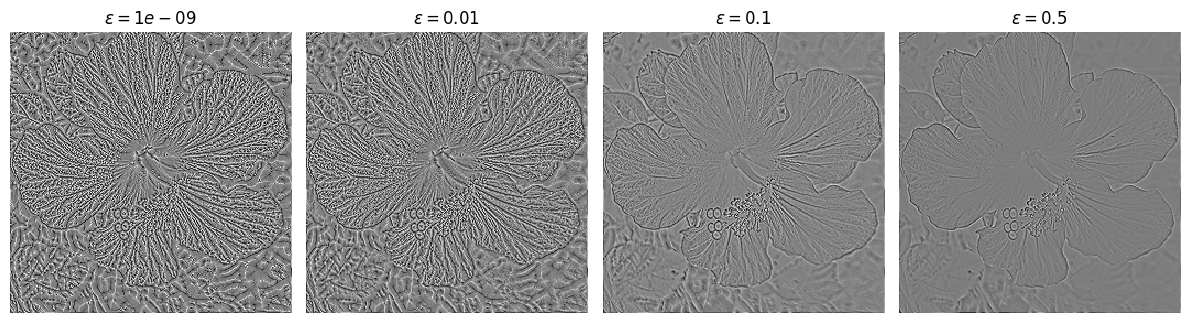

In [123]:
epsilon_list = [1e-9, 1e-2, 1e-1, 0.5]

plt.figure(figsize=(12, 10))

for i, eps in enumerate(epsilon_list, start=1):
    # denom = sqrt(eps^2 + ||∇f||^2)
    denom = np.sqrt(eps**2 + l_2**2)        # l_2 = ||∇f|| (n,n)
    # normalisation composante par composante de Gr
    G = div(Gr / denom[..., None])    # Gr : (n,n,2)
    plt.subplot(1, 4, i)
    imageplot(G, rf"$\epsilon = {eps}$")

plt.tight_layout()
plt.show()

- Pour $\epsilon$ très petit, on est presque sur le TV pur les contours sont très marqués, le champ varie beaucoup et réagit fort au bruit.
- Lorsque $\epsilon$ augmente, la normalisation devient plus douce, les réponses aux gradients faibles sont plus régularisées le gradient TV devient plus lisse, on voit surtout les grandes structures, le bruit fin disparaît.

### __`Régularisation total pour le débruitage`__ 

 - Nous définissons le paramètre de régularisation $\lambda$.
 - Le pas de temps pour la diffusion doit vérifier: $\Large \tau < \frac{2}{1 + \lambda 8 / \varepsilon}$

Le paramètre  $\tau>0$ doit être adapté au niveau de bruit, accroitre sa valeur moyenne rend le débruitage plus agressif. 

In [176]:
epsilon = 1e-2
lambd = .1
tau = 2 / (1 + lambd * 8 / epsilon)
print(f"tau : {tau}")

tau : 0.024691358024691357


`Inintialisation de la minimisation`

- $f_0$ image réelle 
- $y$ image $f_0$ bruitée

`Calcul du Gradiant pour la norme TV lissée`.
Le signe « moins » vient du fait qu’en analyse variationnelle, le gradient au sens de $L_2$ d’une énergie J vaut −div(…), et la descente de gradient utilise l’opposé de ce gradient.

In [180]:
Gr = grad(y)
l_2 = np.sqrt(sum(Gr**2, 3))
G = -div(Gr / np.sqrt(eps**2 + l_2**2))

`Un pas de descente de Gradiant`.

Si $J(f)$ est un fonction continue de l'image $f$, un minimiseur de ce problème peut être calculé par descente de gradient. 
 - Cela définit une suite d’images $f^{(\ell)}$ indexed by $\ell \in \mathbb{N}$ tel que : $ f^{(\ell+1)} = f^{(\ell)} + \tau \left( f^{(\ell)}-y + \lambda \text{Grad}J(f^{(\ell)}) \right). $
 - Notons que $f^{(\ell)}$ converge lorsque $\ell \rightarrow +\infty$ 
 - $\large \tau$ requiert d'être faible, si la fonction $J$ est deux fois différenciable $ \tau < \large \frac{2}{1 + \lambda \max_f \|D^2 J(f)\|}. $
 - Le paramètre  $\tau>0$ doit être adapté au niveau de bruit, accroitre sa valeur moyenne rend le débruitage plus agressif. 

`«Apriori de Sobolev»`
 - L’apriori d’image de Sobolev est un a priori quadratique, c’est‑à‑dire une (pseudo-)norme de Hilbert.
 - « Nous chargeons d’abord une image propre (sans bruit). »

##### `Exercise 3 :` 
 - Calcul de la descente de gradient monitorer la minimisation de l'énergie.

`Gradient de l’énergie totale`
 - On minimise $ E(f) =  \frac{1}{2}\|f - y\|^2 + \lambda J(f) $
 - Le gradient $L_2$ de E est $\nabla E(f) = f − y  + λ.GradJ(f)$
 - Un pas de descente de gradient s’écrit alors  $ f^{(\ell+1)} = f^{(\ell)} - \tau \nabla E(f^{(l)}) = f^{(\ell)} - \tau \left( f^{(\ell)}-y + \lambda \text{Grad}J(f^{(\ell)}) \right)$  

In [190]:
tau = 0.1
niter = 100
E = []

fTV = y.copy()

for it in range(niter):
    # gradient de la partie TV lissée
    Gr = grad(fTV)                                      # (n,n,2)
    l2 = np.sqrt(np.sum(Gr**2, axis=2))               # ||∇f||
    G  = -div(Gr / np.sqrt(eps**2 + l2**2)[..., None])
    # descente de gradient
    fTV = fTV - tau * (fTV - y + lambd * G)
    # énergie actuelle
    J_tv_eps = np.sum(np.sqrt(eps**2 + l2**2))
    E.append(0.5*np.linalg.norm(fTV - y)**2 + lambd*J_tv_eps)

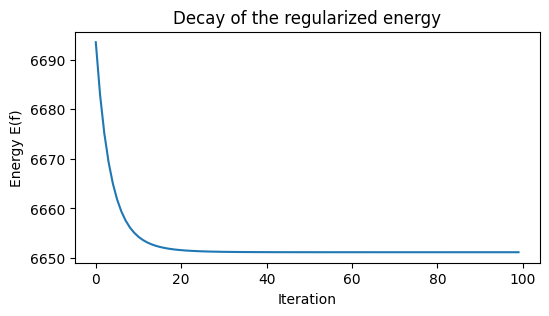

In [191]:
plt.figure(figsize=(6,3))
plt.plot(E)
plt.xlabel('Iteration')
plt.ylabel('Energy E(f)')
plt.title('Decay of the regularized energy')
plt.show()

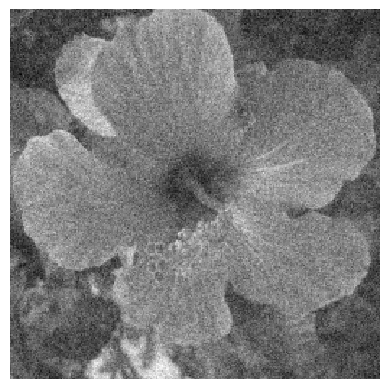

In [189]:
imageplot(fTV)

__Exercise 4__

Compute the solution for several value of $\lambda$ and choose the
optimal $\lambda$ and the corresponding optimal denoising |fSob0|.
You can increase progressively $\lambda$ and reduce
considerably the number of iterations.

In [ ]:
solutions.exo4()

In [ ]:
## Insert your code here.

Display best "oracle" denoising result.

In [ ]:
etvr = snr(f0, fTV0)

imageplot(clamp(y), strcat(['Noisy ' num2str(enoisy, 3) 'dB']), 1, 2, 1)
imageplot(clamp(fTV0), strcat(['TV regularization ' num2str(etvr, 3) 'dB']), 1, 2, 2)

__Exercise 5__

Compare the TV denoising with a hard thresholding in a translation
invariant tight frame of wavelets.

In [ ]:
solutions.exo5()

In [ ]:
## Insert your code here.